<a href="https://colab.research.google.com/github/jenish-0926/Weather-Data-Analysis-and-Seasonal-Trend-Visualization-/blob/main/climate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
file_path="/content/drive/MyDrive/project/chennai weather combined_dataset.csv"

In [12]:
import numpy as np
import pandas as pd

In [13]:
data=pd.read_csv(file_path)

In [14]:
data.head()

,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,chennai,01-01-2004,27.1,24.1,25.4,28.9,24.1,25.9,21.1,77.8,...,NaN,NaN,NaN,2004-01-01T06:31:03,2004-01-01T17:53:07,0.29,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,43279099999
1,chennai,02-01-2004,28.1,23.1,24.4,29.3,23.1,24.5,19.6,75.5,...,NaN,NaN,NaN,2004-01-02T06:31:27,2004-01-02T17:53:41,0.32,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,43279099999
2,chennai,03-01-2004,28.1,21.1,24.6,28.6,21.1,24.9,18.2,68.3,...,NaN,NaN,NaN,2004-01-03T06:31:49,2004-01-03T17:54:15,0.36,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,43279099999
3,chennai,04-01-2004,28.1,19.1,24.1,28.6,19.1,24.2,17.7,68.9,...,NaN,NaN,NaN,2004-01-04T06:32:10,2004-01-04T17:54:49,0.39,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,43279099999
4,chennai,05-01-2004,28.1,22.1,24.5,29.3,22.1,24.8,19.4,74.3,...,NaN,NaN,NaN,2004-01-05T06:32:31,2004-01-05T17:55:23,0.42,Partially cloudy,Partly cloudy throughout the day.,partly-cloudy-day,43279099999


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7551 entries, 0 to 7550
Data columns (total 33 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              7551 non-null   object 
 1   datetime          7551 non-null   object 
 2   tempmax           7551 non-null   float64
 3   tempmin           7551 non-null   float64
 4   temp              7551 non-null   float64
 5   feelslikemax      7551 non-null   float64
 6   feelslikemin      7551 non-null   float64
 7   feelslike         7551 non-null   float64
 8   dew               7551 non-null   float64
 9   humidity          7551 non-null   float64
 10  precip            7551 non-null   float64
 11  precipprob        7551 non-null   int64  
 12  precipcover       7551 non-null   float64
 13  preciptype        2615 non-null   object 
 14  snow              3533 non-null   float64
 15  snowdepth         3527 non-null   float64
 16  windgust          3533 non-null   float64


In [16]:
data.columns

Index(['name', 'datetime', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'precipcover', 'preciptype', 'snow', 'snowdepth', 'windgust',
       'windspeed', 'winddir', 'sealevelpressure', 'cloudcover', 'visibility',
       'solarradiation', 'solarenergy', 'uvindex', 'severerisk', 'sunrise',
       'sunset', 'moonphase', 'conditions', 'description', 'icon', 'stations'],
      dtype='object')

In [17]:
data.isnull().sum()

,0
name,0
datetime,0
tempmax,0
tempmin,0
temp,0
feelslikemax,0
feelslikemin,0
feelslike,0
dew,0
humidity,0


In [18]:
data=data.drop(columns=["severerisk","uvindex","solarenergy","solarradiation","windgust","snowdepth","snow","preciptype"])

In [19]:
data.isnull().sum()

,0
name,0
datetime,0
tempmax,0
tempmin,0
temp,0
feelslikemax,0
feelslikemin,0
feelslike,0
dew,0
humidity,0


In [20]:
data=data.fillna(data.mean(numeric_only=True))

In [21]:
data.isnull().sum()

,0
name,0
datetime,0
tempmax,0
tempmin,0
temp,0
feelslikemax,0
feelslikemin,0
feelslike,0
dew,0
humidity,0


In [22]:
data.describe()


,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipprob,precipcover,windspeed,winddir,sealevelpressure,cloudcover,visibility,moonphase
count,7551.000000,7551.000000,7551.000000,7551.000000,7551.000000,7551.000000,7551.000000,7551.000000,7551.000000,7551.000000,7551.000000,7551.000000,7551.000000,7551.000000,7551.000000,7551.000000,7551.000000
mean,34.673407,26.704344,30.211297,40.266455,28.180095,33.870693,24.344815,72.901563,4.533363,31.611707,2.730121,20.374493,153.309580,1008.470717,52.526348,5.760408,0.484123
std,10.084190,9.056312,9.416900,12.789419,10.500180,11.544614,8.698078,8.720504,17.366154,46.499000,6.899525,5.550535,86.495582,3.852690,20.488568,1.087184,0.288610
min,22.100000,17.100000,21.200000,22.100000,17.100000,21.200000,14.600000,41.400000,0.000000,0.000000,0.000000,0.000000,0.200000,970.800000,0.000000,1.500000,0.000000
25%,31.000000,23.700000,26.700000,34.300000,23.700000,28.000000,21.800000,67.900000,0.000000,0.000000,0.000000,16.900000,69.350000,1005.400000,37.500000,5.100000,0.250000
50%,33.100000,25.500000,29.100000,39.100000,25.500000,32.600000,23.400000,73.000000,0.000000,0.000000,0.000000,20.500000,160.700000,1008.400000,49.600000,5.900000,0.500000
75%,36.000000,27.200000,30.900000,42.300000,30.700000,36.000000,24.600000,78.300000,0.400000,100.000000,4.170000,23.000000,226.900000,1011.600000,67.400000,6.500000,0.750000
max,105.800000,89.200000,94.700000,143.000000,107.300000,115.900000,82.900000,98.800000,428.578000,100.000000,100.000000,119.700000,360.000000,1018.300000,100.000000,13.000000,0.980000


In [23]:
data.corr(numeric_only=True)

,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,precipprob,precipcover,windspeed,winddir,sealevelpressure,cloudcover,visibility,moonphase
tempmax,1.000000,0.977536,0.992352,0.975594,0.958150,0.977576,0.949395,-0.196333,-0.111956,-0.040015,-0.064352,-0.094509,0.242946,-0.275518,-0.041317,-0.102632,0.002724
tempmin,0.977536,1.000000,0.993592,0.964805,0.981597,0.980077,0.975390,-0.099127,-0.067457,0.010321,-0.006639,-0.111257,0.224756,-0.267276,0.065387,-0.165323,0.000816
temp,0.992352,0.993592,1.000000,0.972315,0.970991,0.983078,0.970211,-0.145073,-0.089770,-0.015544,-0.035907,-0.107220,0.227414,-0.261871,0.014865,-0.140718,0.001381
feelslikemax,0.975594,0.964805,0.972315,1.000000,0.962092,0.989447,0.950166,-0.122956,-0.100568,-0.002758,-0.043591,-0.072554,0.293194,-0.330625,-0.004029,-0.069594,0.003428
feelslikemin,0.958150,0.981597,0.970991,0.962092,1.000000,0.983694,0.941121,-0.151231,-0.090899,-0.032005,-0.040139,-0.067817,0.266657,-0.326817,0.032305,-0.092885,-0.000204
feelslike,0.977576,0.980077,0.983078,0.989447,0.983694,1.000000,0.953646,-0.153718,-0.105566,-0.016752,-0.052115,-0.065660,0.297056,-0.341760,0.009122,-0.063834,0.001641
dew,0.949395,0.975390,0.970211,0.950166,0.941121,0.953646,1.000000,0.096503,-0.010492,0.073019,0.055264,-0.167539,0.156887,-0.178120,0.087914,-0.276318,0.002241
humidity,-0.196333,-0.099127,-0.145073,-0.122956,-0.151231,-0.153718,0.096503,1.000000,0.364007,0.374598,0.402490,-0.251585,-0.308851,0.360883,0.298777,-0.596352,0.008075
precip,-0.111956,-0.067457,-0.089770,-0.100568,-0.090899,-0.105566,-0.010492,0.364007,1.000000,0.383983,0.505029,0.093699,0.034451,-0.046440,0.356110,-0.317616,-0.004678
precipprob,-0.040015,0.010321,-0.015544,-0.002758,-0.032005,-0.016752,0.073019,0.374598,0.383983,1.000000,0.582047,0.004849,0.179905,-0.184683,0.575296,-0.243069,0.012988


In [24]:
import matplotlib.pyplot as plt

In [25]:
data.columns

Index(['name', 'datetime', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'precipcover', 'windspeed', 'winddir', 'sealevelpressure', 'cloudcover',
       'visibility', 'sunrise', 'sunset', 'moonphase', 'conditions',
       'description', 'icon', 'stations'],
      dtype='object')

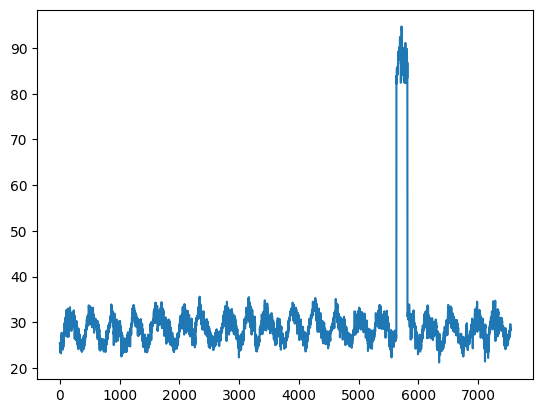

In [26]:
plt.plot(data["temp"])
plt.show()

In [27]:
data["datetime"] = pd.to_datetime(data["datetime"], dayfirst=True)

In [28]:
data["month"] = data["datetime"].dt.month

In [29]:
rain = data.groupby("month")["precip"].sum()

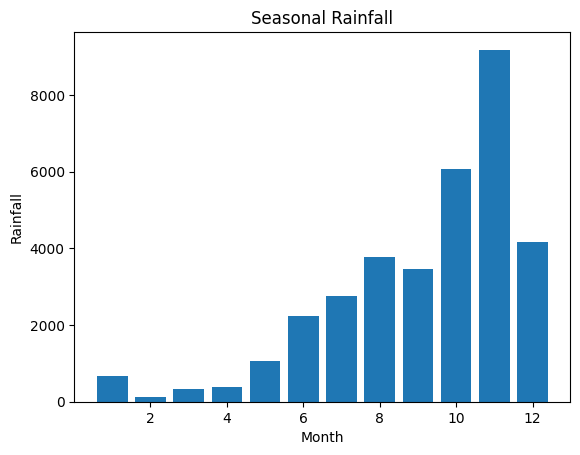

In [30]:
import matplotlib.pyplot as plt

plt.bar(rain.index, rain.values)

plt.title("Seasonal Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall")

plt.show()

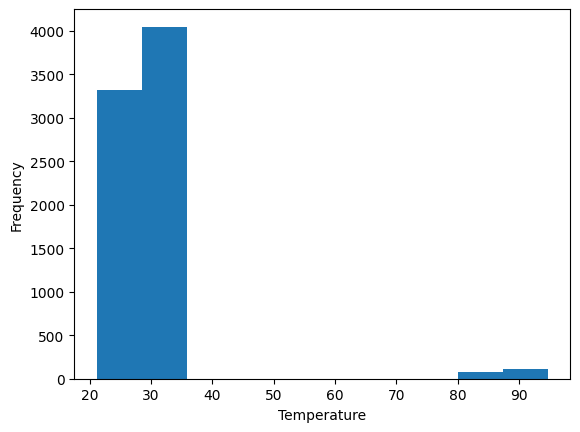

In [31]:
plt.hist(data["temp"])
plt.xlabel("Temperature")
plt.ylabel("Frequency")
plt.show()

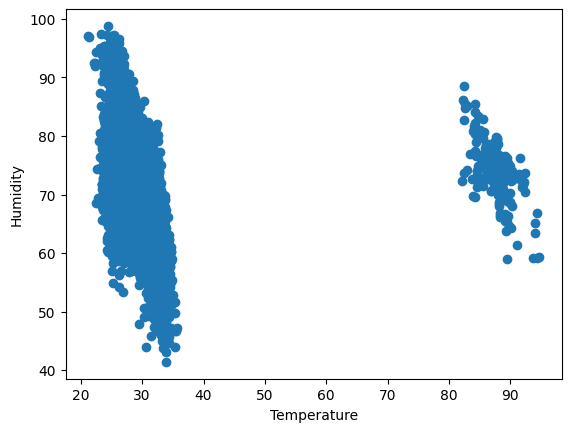

In [32]:
plt.scatter(data["temp"],data["humidity"])
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()

In [33]:
def get_season(m):
    if m in [12,1,2]:
        return "Winter"
    elif m in [3,4,5]:
        return "Summer"
    elif m in [6,7,8,9]:
        return "Monsoon"
    else:
        return "PostMonsoon"

data["season"] = data["month"].apply(get_season)

In [34]:
season_count = data["season"].value_counts()

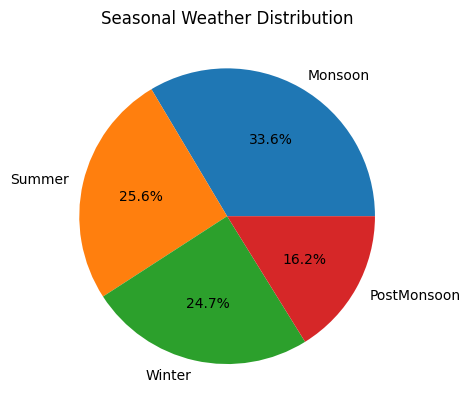

In [35]:
import matplotlib.pyplot as plt

plt.pie(season_count.values,
        labels=season_count.index,
        autopct="%1.1f%%")

plt.title("Seasonal Weather Distribution")

plt.show()

In [36]:
print("Temperature trend, rainfall comparison, and weather patterns can be observed from the graphs.")

Temperature trend, rainfall comparison, and weather patterns can be observed from the graphs.
